# Distribution Explorer for Manual Threshold Setting

Purpose: provide a deep view of each rule's distribution so the researcher
can read the data and set thresholds manually rather than via quantile
calibration.

## Why this notebook exists

The previous calibration approach (Threshold Calibration v1, v2) used
percentile-based methods (p75, p90, bimodal valley) to derive thresholds.
The fundamental issue: percentile methods assume you know what fraction of
data is "bad" in advance. They flag the worst N% by definition, regardless
of whether those N% are actually bad.

For setting **quality standards**, the question "where is the cliff
between acceptable and unacceptable on this metric?" manual inspection
of the distribution is more appropriate than automated calibration. This
notebook provides the data and visualizations needed to make that decision
informed by evidence rather than guessed.

## What this notebook does NOT do

- No automatic threshold derivation
- No bimodal valley algorithm output as a decision driver
- No reference-dict accommodation logic
- No "high/medium/low confidence" tagging
- No connection to existing tier classifications (those depend on the
  threshold you're about to set, so referring to them would be circular)

Distribution shape diagnostics (dip p-value, skewness) are still reported
as **information**, not as decision drivers. They help you see whether the
distribution is unimodal, bimodal, or skewed.

## Rules in scope (12 total)

1. `morph_low_tag_coverage`
2. `morph_too_few_rows`
3. `morph_low_retention`
4. `billex_high_multiword_ind`
5. `billex_too_few_rows`
6. `billex_high_null_rate`
7. `billex_low_retention`
8. `parcor_high_placeholders`
9. `parcor_too_few_rows`
10. `parcor_low_retention`
11. `parcor_high_null_rate`
12. `parcor_high_short_rows`

Each rule gets a self-contained section with: distribution diagnostics,
histogram with what-if threshold lines, per-dict ranked table, and a
candidate-threshold table.

## Output files (in `../csvAnalysis/distribution_exploration/`)

- `_per_rule_distributions.csv`: every dict's metric value for every rule
- `_my_thresholds.csv`: empty template for you to fill in your decisions
- One CSV per rule with the per-dict values and rank: `_<rule_name>.csv`

These are decision-support artifacts, not deliverables. Once you've used
them to make threshold decisions, you'll write the chosen thresholds into
`_my_thresholds.csv` and feed them into the next iteration of sanity
checks.

## 1. Configuration & loading

In [1]:
import re
import ast
from pathlib import Path
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import diptest

from _common import parse_dict_id, load_direction_lookup, direction_for

DIRS = {
    "prep":   Path("../Ekstraksi/6. Pemecahan Definisi Lema"),
    "billex": Path("../Ekstraksi/9. Bilingual Lexicon"),
    "morph":  Path("../Ekstraksi/10. Morphology"),
    "parcor": Path("../Ekstraksi/11. Parallel Corpus"),
}
DST_DIR = Path("../csvAnalysis/distribution_exploration_1")
DST_DIR.mkdir(parents=True, exist_ok=True)
RETENTION_MIN_PREP_ROWS = 100  # below this, retention is undefined

print(f"Output dir: {DST_DIR.resolve()}")

Output dir: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\distribution_exploration_1


## 2. Load per-dict metrics

In [2]:
def parse_list_cell(s):
    if isinstance(s, list): return s
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []


def collect_billex_metrics(path: Path, direction: Optional[int]) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0 or "kata_asal" not in df.columns or "kata_tujuan" not in df.columns:
        return {"billex_rows": n}
    if direction == 1:
        ind_col, reg_col = "kata_asal", "kata_tujuan"
    else:
        ind_col, reg_col = "kata_tujuan", "kata_asal"

    def first_of(v):
        if not isinstance(v, str): return ""
        lst = parse_list_cell(v)
        if lst:
            first = lst[0]
            return str(first).strip() if first is not None else ""
        return v.strip()

    if direction == 1:
        ind_series = df[ind_col].fillna("").astype(str).str.strip()
    else:
        ind_series = df[ind_col].apply(first_of)

    null_rate = df[[ind_col, reg_col]].isna().any(axis=1).mean()
    multiword_ind_rate = ind_series.str.contains(r"\s", na=False, regex=True).mean()
    return {
        "billex_rows": n,
        "billex_complete_pair_rate":      round(float(1 - null_rate), 4),
        "billex_single_word_headword_rate": round(float(1 - multiword_ind_rate), 4),
    }


def collect_morph_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"morph_rows": 0}
    if "tag" in df.columns:
        tag_col = df["tag"].fillna("").astype(str).str.strip()
        rate = ((tag_col != "") & (tag_col.str.lower() != "nan")).mean()
    else:
        rate = 0.0
    return {"morph_rows": n, "morph_tag_coverage": round(float(rate), 4)}


def collect_parcor_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"parcor_rows": 0}
    if "kalimat_asal" not in df.columns or "kalimat_tujuan" not in df.columns:
        return {"parcor_rows": n, "parcor_complete_pair_rate": 0.0}
    asal = df["kalimat_asal"].fillna("").astype(str)
    tujuan = df["kalimat_tujuan"].fillna("").astype(str)
    null_rate = df[["kalimat_asal", "kalimat_tujuan"]].isna().any(axis=1).mean()
    placeholder_re = re.compile(r"(?:^|\s)(--|-)(?=\s|$|[.,;:!?])")
    ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
    len_asal = asal.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    len_tujuan = tujuan.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    short_rate = ((len_asal <= 2) | (len_tujuan <= 2)).mean()
    return {
        "parcor_rows": n,
        "parcor_complete_pair_rate": round(float(1 - null_rate), 4),
        "parcor_valid_content_rate": round(float(1 - ph_rate), 4),
        "parcor_valid_length_rate":  round(float(1 - short_rate), 4),
    }


def get_prep_rows(dict_id: str) -> int:
    if not DIRS["prep"].exists(): return 0
    files = list(DIRS["prep"].glob(f"{dict_id}_*.csv"))
    if not files: return 0
    try: return len(pd.read_csv(files[0]))
    except Exception: return 0


def find_csv(dir_: Path, dict_id: str, suffix: str) -> Optional[Path]:
    if not dir_.exists(): return None
    matches = list(dir_.glob(f"{dict_id}_{suffix}.csv"))
    return matches[0] if matches else None


billex_files = sorted(DIRS["billex"].glob("*_Billex.csv")) if DIRS["billex"].exists() else []
dict_ids = sorted({parse_dict_id(p.name) for p in billex_files} - {None}, key=lambda s: int(s))
direction_lookup = load_direction_lookup()

rows = []
for dict_id in dict_ids:
    m = {"dict_id": dict_id, "direction": direction_for(dict_id, direction_lookup)}
    m["prep_rows"] = get_prep_rows(dict_id)

    p_b = find_csv(DIRS["billex"], dict_id, "Billex")
    if p_b: m.update(collect_billex_metrics(p_b, m["direction"] or 1))

    p_m = find_csv(DIRS["morph"], dict_id, "Morphology")
    if p_m: m.update(collect_morph_metrics(p_m))

    p_p = find_csv(DIRS["parcor"], dict_id, "Parcor")
    if p_p: m.update(collect_parcor_metrics(p_p))

    # Billex retention only (per scope decision)
    if m["prep_rows"] >= RETENTION_MIN_PREP_ROWS and "billex_rows" in m:
        m["billex_retention"] = round(m["billex_rows"] / m["prep_rows"], 4)
    else:
        m["billex_retention"] = np.nan

    rows.append(m)

metrics_df = pd.DataFrame(rows).sort_values("dict_id", key=lambda s: s.astype(int)).reset_index(drop=True)
print(f"Loaded {len(metrics_df)} dictionaries")
print(f"\nAvailable columns: {[c for c in metrics_df.columns if c not in ['dict_id', 'direction']]}")


C:\Users\Legion\AppData\Local\Temp\ipykernel_18916\2786767678.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_18916\2786767678.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_18916\2786767678.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_18916\2786767678.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually 

Loaded 68 dictionaries

Available columns: ['prep_rows', 'billex_rows', 'billex_complete_pair_rate', 'billex_single_word_headword_rate', 'morph_rows', 'morph_tag_coverage', 'parcor_rows', 'parcor_complete_pair_rate', 'parcor_valid_content_rate', 'parcor_valid_length_rate', 'billex_retention']


C:\Users\Legion\AppData\Local\Temp\ipykernel_18916\2786767678.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_18916\2786767678.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()


## 3. Helper: `explore_rule`

Single function that produces, for one rule:
- Distribution diagnostics (5-number summary, dip p, skewness)
- Histogram with candidate-threshold lines
- Sorted per-dict table (worst first)
- What-if threshold table (quantile grid + distribution landmarks)
- Per-rule CSV output

In [3]:
def explore_rule(rule_name: str, metric_col: str, direction: str):
    """
    Per-rule deep exploration. Prints diagnostics, draws histogram,
    saves per-dict CSV. No threshold decision is made here.
    """
    if metric_col not in metrics_df.columns:
        print(f"⚠ Column {metric_col} not in metrics_df. Skipping.")
        return

    # Pull values, dropping NaN for stats but keeping in per-dict list as 'n/a'
    # Build column list, deduplicating to handle metric_col == one of the context columns
    base_cols = ["dict_id", "prep_rows", "billex_rows", "morph_rows", "parcor_rows"]
    cols_needed = base_cols + ([metric_col] if metric_col not in base_cols else [])
    sub = metrics_df[cols_needed].copy()
    valid = sub.dropna(subset=[metric_col]).copy()
    values = valid[metric_col].values.astype(float)

    if len(values) < 5:
        print(f"⚠ Insufficient data for {rule_name}: only {len(values)} valid values")
        return

    # === SECTION A: Distribution diagnostics ===
    n_total = len(metrics_df)
    n_valid = len(values)
    n_na = n_total - n_valid

    p1, p5, p10, p25, p50, p75, p90, p95, p99 = np.percentile(
        values, [1, 5, 10, 25, 50, 75, 90, 95, 99]
    )
    mean = float(np.mean(values))
    std  = float(np.std(values))
    # Force 1-D array — guards against accidentally 2-D inputs from unusual columns
    values = np.asarray(values).ravel().astype(float)
    values = values[~np.isnan(values)]

    if std > 1e-9 and len(values) >= 3:
        # Try multiple skewness implementations, falling back as needed
        try:
            skewness = float(pd.Series(values).skew())  # pandas: most robust
            if np.isnan(skewness):
                skewness = 0.0
        except Exception:
            try:
                raw = np.asarray(stats.skew(values, bias=True)).flatten()
                skewness = float(raw[0]) if len(raw) > 0 else 0.0
                if np.isnan(skewness):
                    skewness = 0.0
            except Exception:
                skewness = 0.0
    else:
        skewness = 0.0
    try:
        dip_stat, dip_pval = diptest.diptest(values)
    except Exception:
        dip_stat, dip_pval = float("nan"), float("nan")

    print(f"=== {rule_name} ===\n")
    print(f"Metric: {metric_col}    Direction: {direction} ({'low=bad' if direction=='low' else 'high=bad'})")
    print(f"Coverage: {n_valid} valid values, {n_na} N/A "
          f"({n_na/n_total:.1%} missing)\n")

    print(f"Summary statistics:")
    print(f"  min: {values.min():.4f}    max: {values.max():.4f}")
    print(f"  mean: {mean:.4f}    median: {p50:.4f}    std: {std:.4f}")
    print(f"  skewness: {skewness:+.3f}    dip-test p-value: {dip_pval:.4f}")
    print(f"  shape hint: ", end="")
    if dip_pval < 0.05:
        print("BIMODAL (clear separation between two populations)")
    elif abs(skewness) > 1.5:
        print(f"STRONGLY SKEWED ({'right' if skewness > 0 else 'left'} tail)")
    elif abs(skewness) > 0.5:
        print(f"MILDLY SKEWED ({'right' if skewness > 0 else 'left'} tail)")
    else:
        print("APPROXIMATELY SYMMETRIC")

    print(f"\nPercentiles:")
    print(f"  p1={p1:.4f}  p5={p5:.4f}  p10={p10:.4f}  p25={p25:.4f}")
    print(f"  p50={p50:.4f}  p75={p75:.4f}  p90={p90:.4f}  p95={p95:.4f}  p99={p99:.4f}")

    # === SECTION B: Candidate threshold table ===
    # Combine quantile grid (A) and distribution landmarks (B)
    landmarks = []
    quantiles = [
        ("p5",  p5), ("p10", p10), ("p25", p25), ("p50", p50),
        ("p75", p75), ("p90", p90), ("p95", p95),
    ]
    landmarks_extra = [
        ("mean",       mean),
        ("mean − 1σ",  mean - std),
        ("mean − 2σ",  mean - 2 * std),
        ("mean + 1σ",  mean + std),
        ("mean + 2σ",  mean + 2 * std),
    ]

    candidates = quantiles + landmarks_extra

    print(f"\nWhat-if threshold table:")
    print(f"  threshold | flag count | flag rate | type")
    print(f"  ---------|-----------|-----------|-----------")
    for label, candidate in candidates:
        if direction == "low":
            n_flagged = int((values < candidate).sum())
        else:
            n_flagged = int((values > candidate).sum())
        flag_rate = n_flagged / n_valid
        kind = "quantile" if label.startswith("p") else "landmark"
        print(f"  {label:<10} | {candidate:>9.4f} | {n_flagged:>6} ({flag_rate:>5.1%}) | {kind}")

    # === SECTION C: Histogram with candidate threshold lines ===
    fig, ax = plt.subplots(figsize=(11, 5))

    n_bins = min(30, max(10, int(np.sqrt(n_valid))))
    ax.hist(values, bins=n_bins, color="#90a4ae", edgecolor="white", alpha=0.85)

    # Draw quantile lines
    quantile_colors = {"p25": "#1976d2", "p50": "#388e3c", "p75": "#1976d2"}
    for label, candidate in [("p25", p25), ("p50", p50), ("p75", p75)]:
        ax.axvline(candidate, color=quantile_colors[label], linestyle=":",
                   linewidth=1.2, alpha=0.6, label=f"{label}={candidate:.3f}")
    # Mean
    ax.axvline(mean, color="#f57c00", linestyle="-.", linewidth=1.2, alpha=0.7,
               label=f"mean={mean:.3f}")

    ax.set_xlabel(metric_col)
    ax.set_ylabel("Number of dictionaries")
    direction_phrase = "low values are bad" if direction == "low" else "high values are bad"
    ax.set_title(f"{rule_name} — distribution\n({direction_phrase}; "
                  f"skew={skewness:+.2f}, dip-p={dip_pval:.3f}, n={n_valid})",
                  fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # === SECTION D: Per-dict ranked table ===
    # Sort: ascending if direction=low (bad first), descending if direction=high (bad first)
    sort_ascending = (direction == "low")

    valid_sorted = valid.sort_values(metric_col, ascending=sort_ascending).reset_index(drop=True)
    valid_sorted["rank"] = valid_sorted.index + 1

    # Re-order columns for display
    display_cols = ["rank", "dict_id", metric_col, "prep_rows",
                    "billex_rows", "morph_rows", "parcor_rows"]
    display_cols = [c for c in display_cols if c in valid_sorted.columns]

    # NaN dicts at the bottom
    na_sub = sub[sub[metric_col].isna()].copy()
    if len(na_sub) > 0:
        na_sub["rank"] = "n/a"
        na_sub = na_sub[display_cols]
        full_table = pd.concat([valid_sorted[display_cols], na_sub], ignore_index=True)
    else:
        full_table = valid_sorted[display_cols]

    print(f"\nPer-dict ranked table (worst first):")
    print(f"  Top 15 worst:")
    print(full_table.head(15).to_string(index=False))
    print(f"  ...")
    print(f"  Bottom 5 best:")
    if len(full_table) > 20:
        print(full_table[full_table["rank"] != "n/a"].tail(5).to_string(index=False))
    if len(na_sub) > 0:
        print(f"\n  N/A dicts ({len(na_sub)}): {', '.join(na_sub['dict_id'].astype(str).tolist())}")

    # Save per-rule CSV
    csv_path = DST_DIR / f"_{rule_name}.csv"
    full_table.to_csv(csv_path, index=False)
    print(f"\nFull table saved: {csv_path}")

    print()

In [4]:
print(metrics_df["morph_rows"].apply(type).value_counts())
print(metrics_df["morph_rows"].head(20).to_list())

morph_rows
<class 'int'>    68
Name: count, dtype: int64
[6, 12, 1, 728, 820, 124, 8, 1125, 205, 2645, 143, 93, 155, 471, 4, 2684, 2032, 0, 482, 0]


## 4. Per-rule explorations

Each section runs `explore_rule()` and produces:
- Stats summary
- What-if threshold table
- Histogram with key landmarks marked
- Per-dict ranked CSV (saved to `_<rule_name>.csv`)

Use the per-dict CSVs alongside this notebook to make threshold decisions.
The CSV is sorted with worst-performing dicts at the top.

## 5. `morph_low_tag_coverage`

**Metric:** `morph_tag_coverage`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)


=== morph_low_tag_coverage ===

Metric: morph_tag_coverage    Direction: low (low=bad)
Coverage: 60 valid values, 8 N/A (11.8% missing)

Summary statistics:
  min: 0.0000    max: 0.9811
  mean: 0.3952    median: 0.4222    std: 0.3309
  skewness: +0.107    dip-test p-value: 0.0096
  shape hint: BIMODAL (clear separation between two populations)

Percentiles:
  p1=0.0000  p5=0.0000  p10=0.0000  p25=0.0000
  p50=0.4222  p75=0.6914  p90=0.8212  p95=0.8597  p99=0.9736

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0000 |      0 ( 0.0%) | quantile
  p10        |    0.0000 |      0 ( 0.0%) | quantile
  p25        |    0.0000 |      0 ( 0.0%) | quantile
  p50        |    0.4222 |     30 (50.0%) | quantile
  p75        |    0.6914 |     45 (75.0%) | quantile
  p90        |    0.8212 |     54 (90.0%) | quantile
  p95        |    0.8597 |     57 (95.0%) | quantile
  mean       |    0.3952 |     29 (48.3%) |

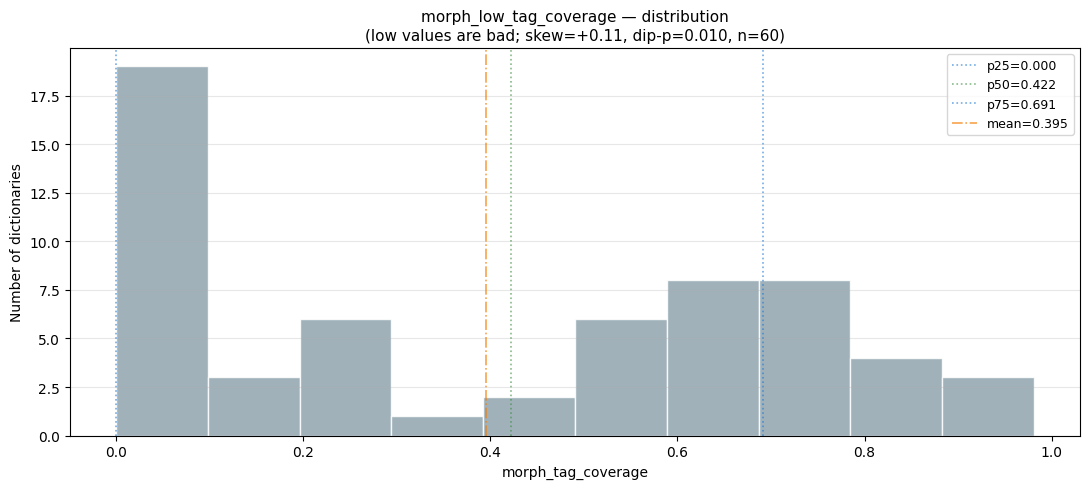


Per-dict ranked table (worst first):
  Top 15 worst:
rank dict_id  morph_tag_coverage  prep_rows  billex_rows  morph_rows  parcor_rows
   1       1                 0.0       3986           16           6         2914
   2       3                 0.0        833           19           1          125
   3       9                 0.0       2240           23           8         1049
   4      17                 0.0       2160            7           4         1673
   5      29                 0.0       1979            1           2         1588
   6      33                 0.0       2899           30          27         1855
   7      84                 0.0       1001            5           2          264
   8      94                 0.0        957           27           5          163
   9      70                 0.0        354          159           3           48
  10      85                 0.0       1239           26           1          532
  11      56                 0.0       3116 

In [5]:
explore_rule(
    rule_name="morph_low_tag_coverage",
    metric_col="morph_tag_coverage",
    direction="low",
)

## 6. `morph_too_few_rows`

**Metric:** `morph_rows`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)


=== morph_too_few_rows ===

Metric: morph_rows    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 4621.0000
  mean: 591.8382    median: 115.0000    std: 976.6229
  skewness: +2.193    dip-test p-value: 0.9667
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=0.0000  p5=0.0000  p10=0.0000  p25=3.7500
  p50=115.0000  p75=728.0000  p90=2217.0000  p95=2670.3500  p99=3982.4900

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0000 |      0 ( 0.0%) | quantile
  p10        |    0.0000 |      0 ( 0.0%) | quantile
  p25        |    3.7500 |     17 (25.0%) | quantile
  p50        |  115.0000 |     34 (50.0%) | quantile
  p75        |  728.0000 |     50 (73.5%) | quantile
  p90        | 2217.0000 |     61 (89.7%) | quantile
  p95        | 2670.3500 |     64 (94.1%) | quantile
  mean       |  591.8382 |     47 (69.1%) | landmark
  m

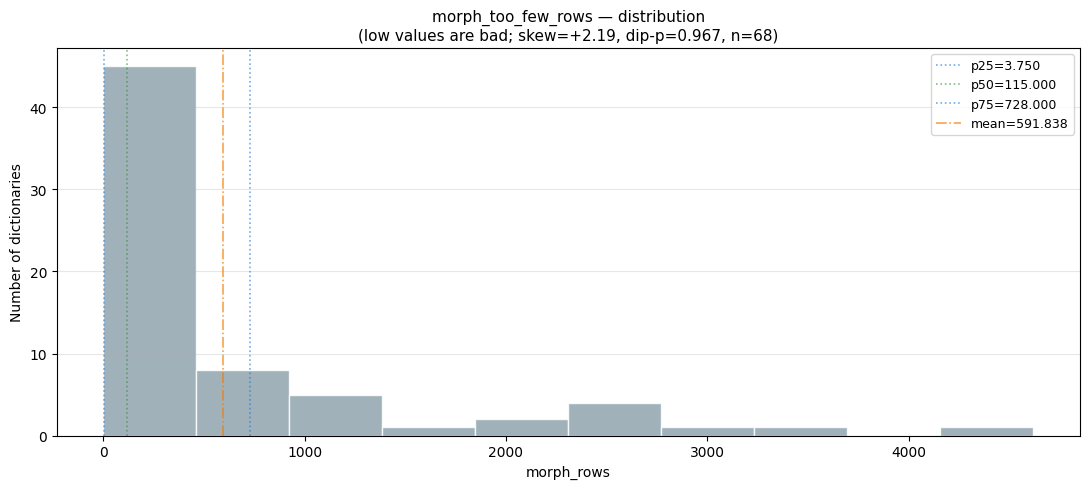


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  morph_rows  prep_rows  billex_rows  morph_rows  parcor_rows
    1      31           0       1371            1           0          566
    2      32           0       3345            5           0         1261
    3      22           0        365            5           0           88
    4      20           0       2109            0           0         1719
    5      78           0       1195            2           0          311
    6      52           0       2679            5           0         2111
    7      48           0        233            1           0          193
    8      44           0       2001            3           0          687
    9       3           1        833           19           1          125
   10      85           1       1239           26           1          532
   11      56           1       3116           13           1         2347
   12      37           2        361          

In [6]:
explore_rule(
    rule_name="morph_too_few_rows",
    metric_col="morph_rows",
    direction="low",
)

## 7. `morph_low_retention`

**Metric:** `morph_retention` (= `morph_rows` / `prep_rows`)
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)

This metric is not currently in the active rule set — `morph_retention` was
dropped earlier because its distribution showed weak structural signal under
calibration. Including it here is for visual re-inspection: with post-fix
data, does the distribution look any more decisive than it did?


=== morph_low_retention ===

Metric: morph_retention    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 0.3502
  mean: 0.1100    median: 0.0802    std: 0.1142
  skewness: +0.580    dip-test p-value: 0.2572
  shape hint: MILDLY SKEWED (right tail)

Percentiles:
  p1=0.0000  p5=0.0000  p10=0.0000  p25=0.0020
  p50=0.0802  p75=0.2131  p90=0.2869  p95=0.3151  p99=0.3421

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0000 |      0 ( 0.0%) | quantile
  p10        |    0.0000 |      0 ( 0.0%) | quantile
  p25        |    0.0020 |     17 (25.0%) | quantile
  p50        |    0.0802 |     34 (50.0%) | quantile
  p75        |    0.2131 |     51 (75.0%) | quantile
  p90        |    0.2869 |     61 (89.7%) | quantile
  p95        |    0.3151 |     64 (94.1%) | quantile
  mean       |    0.1100 |     38 (55.9%) | landmark
  mean − 1σ  |   -0.0

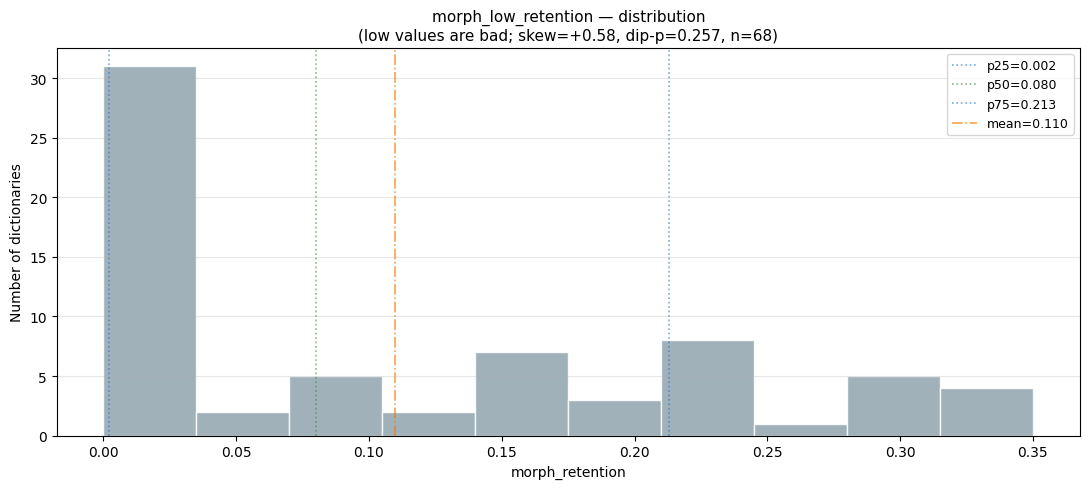


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  morph_retention  prep_rows  billex_rows  morph_rows  parcor_rows
    1      31         0.000000       1371            1           0          566
    2      32         0.000000       3345            5           0         1261
    3      22         0.000000        365            5           0           88
    4      20         0.000000       2109            0           0         1719
    5      78         0.000000       1195            2           0          311
    6      52         0.000000       2679            5           0         2111
    7      48         0.000000        233            1           0          193
    8      44         0.000000       2001            3           0          687
    9      56         0.000321       3116           13           1         2347
   10      61         0.000716       2793            3           2         1090
   11      85         0.000807       1239           26           1

In [7]:
# Compute morph_retention if not already in metrics_df
if "morph_retention" not in metrics_df.columns:
    metrics_df["morph_retention"] = np.where(
        metrics_df["prep_rows"] >= RETENTION_MIN_PREP_ROWS,
        metrics_df["morph_rows"] / metrics_df["prep_rows"],
        np.nan
    )

explore_rule(
    rule_name="morph_low_retention",
    metric_col="morph_retention",
    direction="low",
)

## 8. `billex_low_single_word_headword_rate`

**Metric:** `billex_single_word_headword_rate`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)

_Renamed from `billex_high_multiword_ind` (metric `billex_multiword_ind_rate`); flipped to positive framing for consistency with other rules._


=== billex_low_single_word_headword_rate ===

Metric: billex_single_word_headword_rate    Direction: low (low=bad)
Coverage: 67 valid values, 1 N/A (1.5% missing)

Summary statistics:
  min: 0.0000    max: 1.0000
  mean: 0.6135    median: 0.7789    std: 0.3194
  skewness: -0.812    dip-test p-value: 0.3759
  shape hint: MILDLY SKEWED (left tail)

Percentiles:
  p1=0.0000  p5=0.0000  p10=0.0789  p25=0.3333
  p50=0.7789  p75=0.8599  p90=0.9114  p95=0.9436  p99=0.9813

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0000 |      0 ( 0.0%) | quantile
  p10        |    0.0789 |      7 (10.4%) | quantile
  p25        |    0.3333 |     15 (22.4%) | quantile
  p50        |    0.7789 |     33 (49.3%) | quantile
  p75        |    0.8599 |     50 (74.6%) | quantile
  p90        |    0.9114 |     60 (89.6%) | quantile
  p95        |    0.9436 |     63 (94.0%) | quantile
  mean       |    0.6135 |     25 (37.3%)

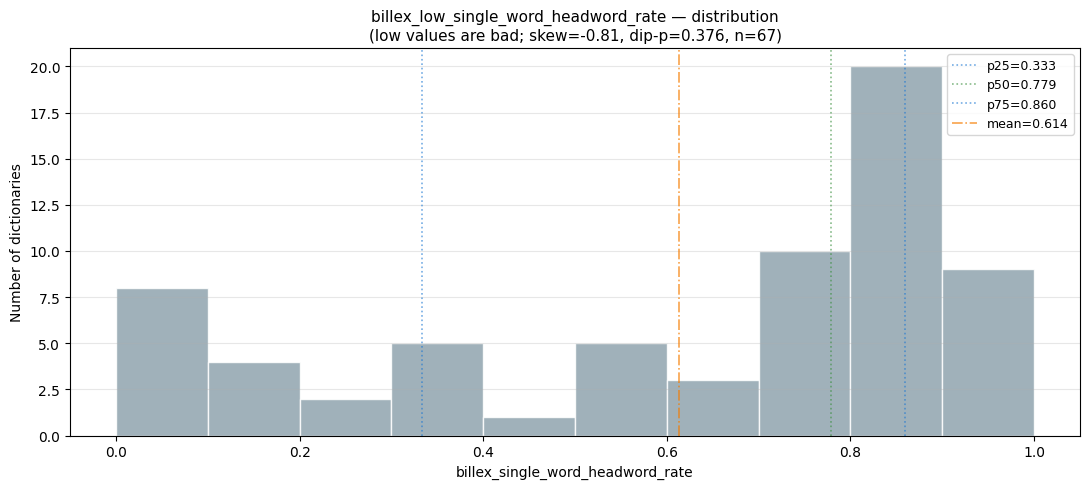


Per-dict ranked table (worst first):
  Top 15 worst:
rank dict_id  billex_single_word_headword_rate  prep_rows  billex_rows  morph_rows  parcor_rows
   1      17                            0.0000       2160            7           4         1673
   2      22                            0.0000        365            5           0           88
   3      29                            0.0000       1979            1           2         1588
   4      48                            0.0000        233            1           0          193
   5      66                            0.0000       1657            2           6         1003
   6      78                            0.0000       1195            2           0          311
   7      60                            0.0667       1643          105           7          942
   8       9                            0.0870       2240           23           8         1049
   9       3                            0.1053        833           19           1

In [8]:
explore_rule(
    rule_name="billex_low_single_word_headword_rate",
    metric_col="billex_single_word_headword_rate",
    direction="low",
)

## 9. `billex_too_few_rows`

**Metric:** `billex_rows`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)


=== billex_too_few_rows ===

Metric: billex_rows    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 10077.0000
  mean: 1584.2941    median: 370.5000    std: 2489.5444
  skewness: +2.019    dip-test p-value: 0.9906
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=0.6700  p5=1.3500  p10=3.0000  p25=22.0000
  p50=370.5000  p75=1899.5000  p90=5485.0000  p95=7513.8500  p99=9943.0000

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    1.3500 |      4 ( 5.9%) | quantile
  p10        |    3.0000 |      6 ( 8.8%) | quantile
  p25        |   22.0000 |     17 (25.0%) | quantile
  p50        |  370.5000 |     34 (50.0%) | quantile
  p75        | 1899.5000 |     51 (75.0%) | quantile
  p90        | 5485.0000 |     61 (89.7%) | quantile
  p95        | 7513.8500 |     64 (94.1%) | quantile
  mean       | 1584.2941 |     49 (72.1%) | landm

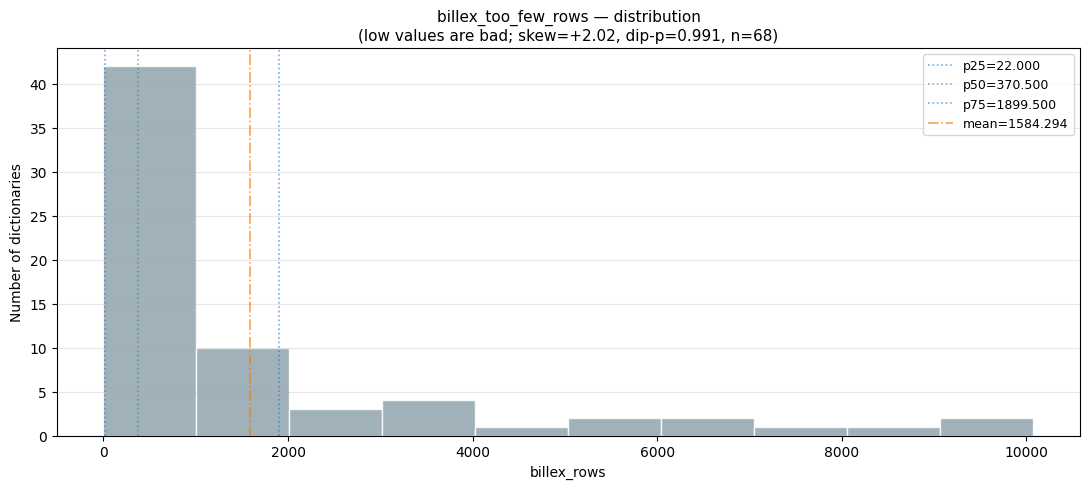


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  billex_rows  prep_rows  billex_rows  morph_rows  parcor_rows
    1      20            0       2109            0           0         1719
    2      31            1       1371            1           0          566
    3      29            1       1979            1           2         1588
    4      48            1        233            1           0          193
    5      66            2       1657            2           6         1003
    6      78            2       1195            2           0          311
    7      44            3       2001            3           0          687
    8      61            3       2793            3           2         1090
    9      32            5       3345            5           0         1261
   10      52            5       2679            5           0         2111
   11      84            5       1001            5           2          264
   12      22            5        

In [9]:
explore_rule(
    rule_name="billex_too_few_rows",
    metric_col="billex_rows",
    direction="low",
)

## 10. `billex_low_complete_pair_rate`

**Metric:** `billex_complete_pair_rate`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)

_Renamed from `billex_high_null_rate` (metric `billex_null_rate`); flipped to positive framing for consistency with other rules._


=== billex_low_complete_pair_rate ===

Metric: billex_complete_pair_rate    Direction: low (low=bad)
Coverage: 67 valid values, 1 N/A (1.5% missing)

Summary statistics:
  min: 0.8889    max: 1.0000
  mean: 0.9971    median: 1.0000    std: 0.0151
  skewness: -6.348    dip-test p-value: 1.0000
  shape hint: STRONGLY SKEWED (left tail)

Percentiles:
  p1=0.9234  p5=0.9950  p10=0.9985  p25=1.0000
  p50=1.0000  p75=1.0000  p90=1.0000  p95=1.0000  p99=1.0000

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.9950 |      3 ( 4.5%) | quantile
  p10        |    0.9985 |      7 (10.4%) | quantile
  p25        |    1.0000 |     14 (20.9%) | quantile
  p50        |    1.0000 |     14 (20.9%) | quantile
  p75        |    1.0000 |     14 (20.9%) | quantile
  p90        |    1.0000 |     14 (20.9%) | quantile
  p95        |    1.0000 |     14 (20.9%) | quantile
  mean       |    0.9971 |      5 ( 7.5%) | landmark


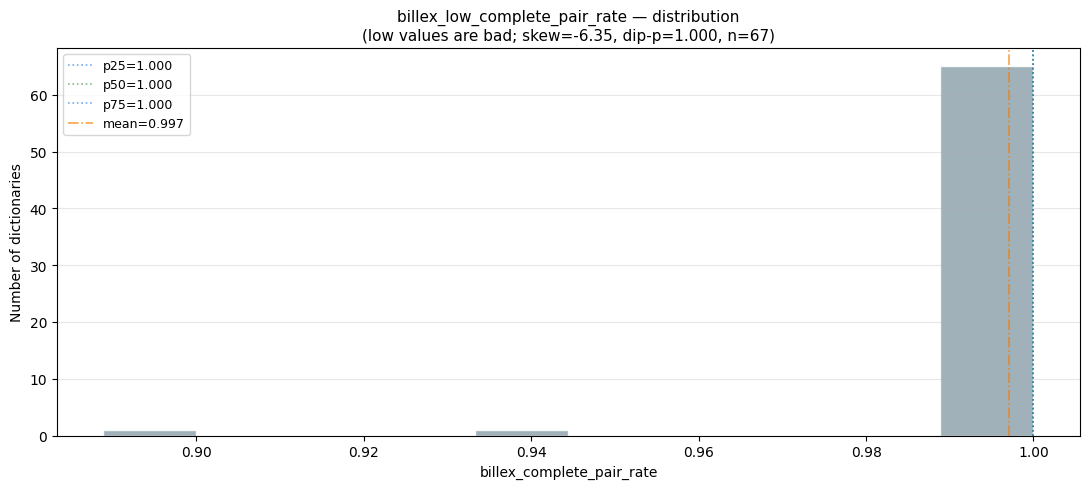


Per-dict ranked table (worst first):
  Top 15 worst:
rank dict_id  billex_complete_pair_rate  prep_rows  billex_rows  morph_rows  parcor_rows
   1      57                     0.8889       2620            9           3         1529
   2      58                     0.9412       5237           34           9         1532
   3      67                     0.9938       3135          162          65          511
   4      15                     0.9950       1495          401         155          711
   5      11                     0.9950       2298          399         205          609
   6      50                     0.9976       1620          410         252          679
   7      68                     0.9984       7546         6936        2343         2044
   8      28                     0.9985       1081          658         183          547
   9      79                     0.9987       1877          754         331          783
  10      36                     0.9993       2788      

In [10]:
explore_rule(
    rule_name="billex_low_complete_pair_rate",
    metric_col="billex_complete_pair_rate",
    direction="low",
)

## 11. `billex_low_retention`

**Metric:** `billex_retention`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)


=== billex_low_retention ===

Metric: billex_retention    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 0.9783
  mean: 0.3215    median: 0.2671    std: 0.3006
  skewness: +0.383    dip-test p-value: 0.0354
  shape hint: BIMODAL (clear separation between two populations)

Percentiles:
  p1=0.0003  p5=0.0011  p10=0.0016  p25=0.0103
  p50=0.2671  p75=0.5945  p90=0.7008  p95=0.8159  p99=0.9451

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0011 |      4 ( 5.9%) | quantile
  p10        |    0.0016 |      7 (10.3%) | quantile
  p25        |    0.0103 |     16 (23.5%) | quantile
  p50        |    0.2671 |     34 (50.0%) | quantile
  p75        |    0.5945 |     51 (75.0%) | quantile
  p90        |    0.7008 |     61 (89.7%) | quantile
  p95        |    0.8159 |     64 (94.1%) | quantile
  mean       |    0.3215 |     35 (51.5%) | land

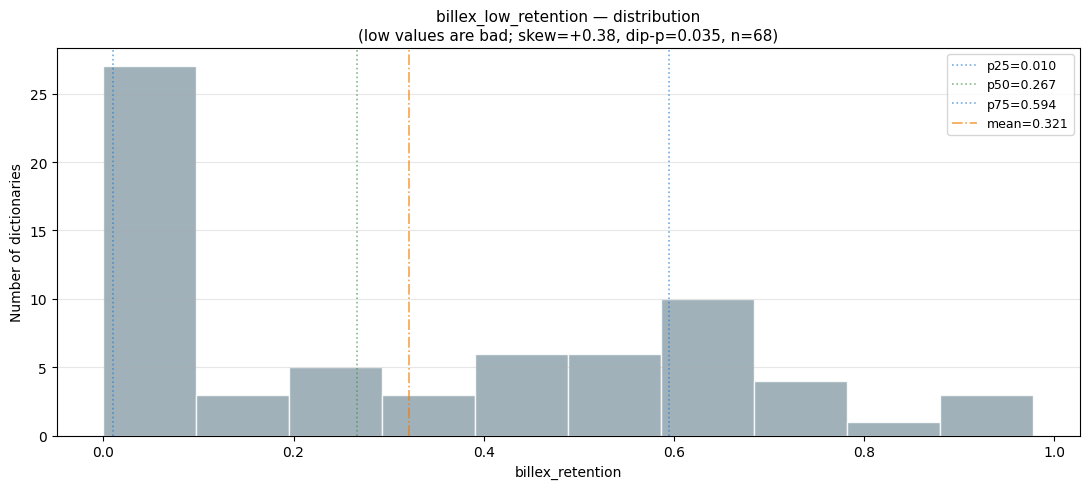


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  billex_retention  prep_rows  billex_rows  morph_rows  parcor_rows
    1      20            0.0000       2109            0           0         1719
    2      29            0.0005       1979            1           2         1588
    3      31            0.0007       1371            1           0          566
    4      61            0.0011       2793            3           2         1090
    5      66            0.0012       1657            2           6         1003
    6      44            0.0015       2001            3           0          687
    7      32            0.0015       3345            5           0         1261
    8      78            0.0017       1195            2           0          311
    9      52            0.0019       2679            5           0         2111
   10      17            0.0032       2160            7           4         1673
   11      57            0.0034       2620            9

In [11]:
explore_rule(
    rule_name="billex_low_retention",
    metric_col="billex_retention",
    direction="low",
)

## 12. `parcor_low_valid_content_rate`

**Metric:** `parcor_valid_content_rate`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)

_Renamed from `parcor_high_placeholders` (metric `parcor_placeholder_rate`); flipped to positive framing for consistency with other rules._


=== parcor_low_valid_content_rate ===

Metric: parcor_valid_content_rate    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.2500    max: 0.9994
  mean: 0.6397    median: 0.6222    std: 0.2019
  skewness: +0.220    dip-test p-value: 0.1183
  shape hint: APPROXIMATELY SYMMETRIC

Percentiles:
  p1=0.2552  p5=0.3401  p10=0.3874  p25=0.4856
  p50=0.6222  p75=0.7681  p90=0.9784  p95=0.9965  p99=0.9992

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.3401 |      4 ( 5.9%) | quantile
  p10        |    0.3874 |      7 (10.3%) | quantile
  p25        |    0.4856 |     17 (25.0%) | quantile
  p50        |    0.6222 |     34 (50.0%) | quantile
  p75        |    0.7681 |     51 (75.0%) | quantile
  p90        |    0.9784 |     61 (89.7%) | quantile
  p95        |    0.9965 |     64 (94.1%) | quantile
  mean       |    0.6397 |     37 (54.4%) | landmark
  me

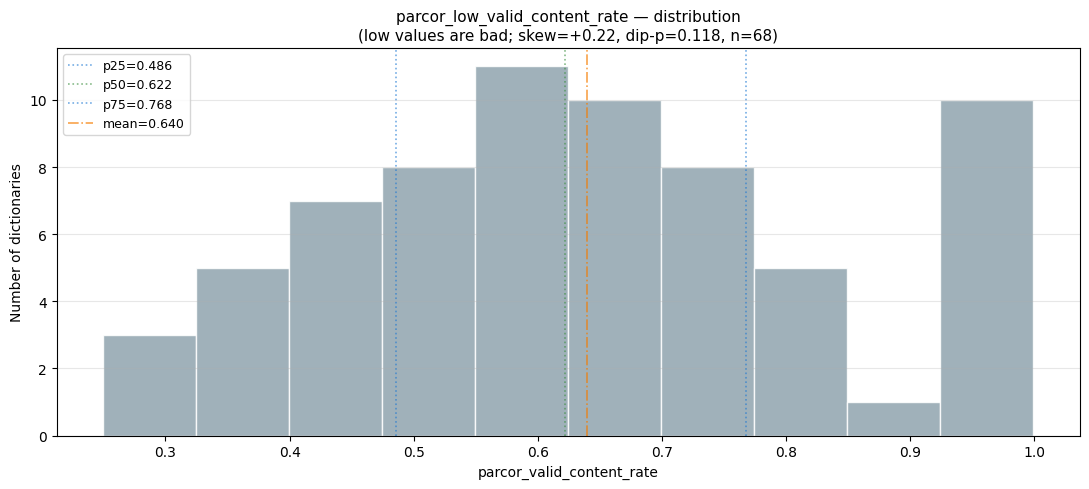


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_valid_content_rate  prep_rows  billex_rows  morph_rows  parcor_rows
    1      70                     0.2500        354          159           3           48
    2      37                     0.2577        361           96           2          260
    3      20                     0.2792       2109            0           0         1719
    4      10                     0.3362       5260         3800        1125         2942
    5       4                     0.3473       3212         1894         728         2658
    6      77                     0.3806       1780         1284         278         1353
    7      21                     0.3834       2990         1485         482         2019
    8      63                     0.3891       1084          256          53          825
    9      55                     0.4030       2668         1508         422         1829
   10      29                     0.4087      

In [12]:
explore_rule(
    rule_name="parcor_low_valid_content_rate",
    metric_col="parcor_valid_content_rate",
    direction="low",
)

## 13. `parcor_too_few_rows`

**Metric:** `parcor_rows`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)


=== parcor_too_few_rows ===

Metric: parcor_rows    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 48.0000    max: 8484.0000
  mean: 1711.7353    median: 1259.5000    std: 1526.7523
  skewness: +1.863    dip-test p-value: 0.9844
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=74.8000  p5=173.5000  p10=262.8000  p25=661.5000
  p50=1259.5000  p75=2293.7500  p90=3689.6000  p95=4637.7500  p99=6537.6500

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |  173.5000 |      4 ( 5.9%) | quantile
  p10        |  262.8000 |      7 (10.3%) | quantile
  p25        |  661.5000 |     17 (25.0%) | quantile
  p50        | 1259.5000 |     34 (50.0%) | quantile
  p75        | 2293.7500 |     51 (75.0%) | quantile
  p90        | 3689.6000 |     61 (89.7%) | quantile
  p95        | 4637.7500 |     64 (94.1%) | quantile
  mean       | 1711.7353 |     40 (58.8%)

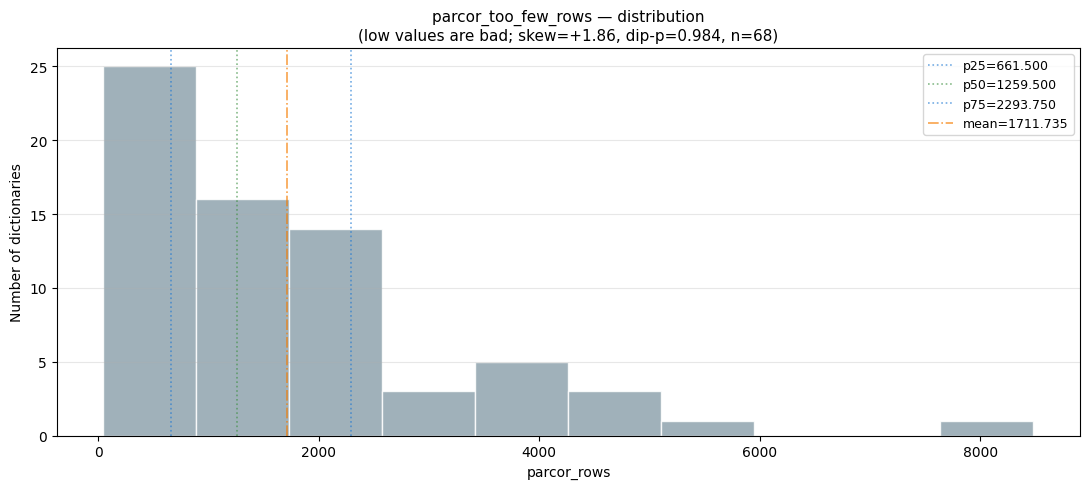


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_rows  prep_rows  billex_rows  morph_rows  parcor_rows
    1      70           48        354          159           3           48
    2      22           88        365            5           0           88
    3       3          125        833           19           1          125
    4      94          163        957           27           5          163
    5      48          193        233            1           0          193
    6      25          195        440          168         143          195
    7      37          260        361           96           2          260
    8      84          264       1001            5           2          264
    9      78          311       1195            2           0          311
   10       8          413       2281          342         124          413
   11      67          511       3135          162          65          511
   12      85          532       1

In [13]:
explore_rule(
    rule_name="parcor_too_few_rows",
    metric_col="parcor_rows",
    direction="low",
)

## 14. `parcor_low_retention`

**Metric:** `parcor_retention` (= `parcor_rows` / `prep_rows`)
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)

Same as morph_retention above: not in the active rule set, included for
visual re-inspection.


=== parcor_low_retention ===

Metric: parcor_retention    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.1248    max: 0.8283
  mean: 0.5030    median: 0.4676    std: 0.2096
  skewness: -0.052    dip-test p-value: 0.1630
  shape hint: APPROXIMATELY SYMMETRIC

Percentiles:
  p1=0.1320  p5=0.1593  p10=0.1810  p25=0.3853
  p50=0.4676  p75=0.6942  p90=0.7959  p95=0.8136  p99=0.8278

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.1593 |      4 ( 5.9%) | quantile
  p10        |    0.1810 |      7 (10.3%) | quantile
  p25        |    0.3853 |     17 (25.0%) | quantile
  p50        |    0.4676 |     34 (50.0%) | quantile
  p75        |    0.6942 |     51 (75.0%) | quantile
  p90        |    0.7959 |     61 (89.7%) | quantile
  p95        |    0.8136 |     64 (94.1%) | quantile
  mean       |    0.5030 |     37 (54.4%) | landmark
  mean − 1σ  |    0.29

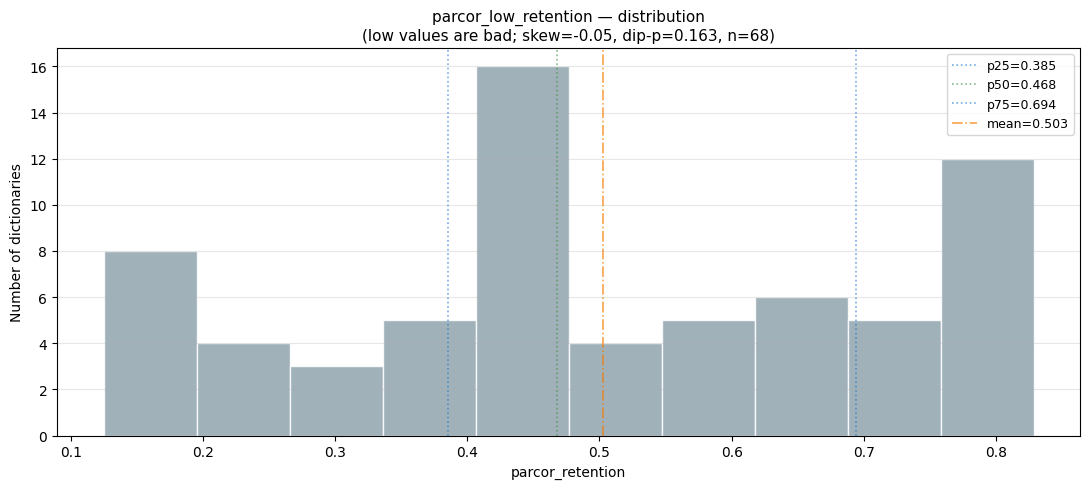


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_retention  prep_rows  billex_rows  morph_rows  parcor_rows
    1      26          0.124815       4735         3137        1014          591
    2      70          0.135593        354          159           3           48
    3       3          0.150060        833           19           1          125
    4      18          0.157368      14876         9877        2684         2341
    5      67          0.162998       3135          162          65          511
    6      94          0.170324        957           27           5          163
    7       5          0.180898       3853         2395         820          697
    8       8          0.181061       2281          342         124          413
    9      22          0.241096        365            5           0           88
   10      78          0.260251       1195            2           0          311
   11      84          0.263736       1001            5

In [14]:
# Compute parcor_retention if not already in metrics_df
if "parcor_retention" not in metrics_df.columns:
    metrics_df["parcor_retention"] = np.where(
        metrics_df["prep_rows"] >= RETENTION_MIN_PREP_ROWS,
        metrics_df["parcor_rows"] / metrics_df["prep_rows"],
        np.nan
    )

explore_rule(
    rule_name="parcor_low_retention",
    metric_col="parcor_retention",
    direction="low",
)

## 15. `parcor_low_complete_pair_rate`

**Metric:** `parcor_complete_pair_rate`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)

_Renamed from `parcor_high_null_rate` (metric `parcor_null_rate`); flipped to positive framing for consistency with other rules._


=== parcor_low_complete_pair_rate ===

Metric: parcor_complete_pair_rate    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.8210    max: 1.0000
  mean: 0.9612    median: 0.9735    std: 0.0418
  skewness: -1.716    dip-test p-value: 0.6108
  shape hint: STRONGLY SKEWED (left tail)

Percentiles:
  p1=0.8241  p5=0.8733  p10=0.8879  p25=0.9500
  p50=0.9735  p75=0.9892  p90=0.9968  p95=0.9990  p99=1.0000

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.8733 |      4 ( 5.9%) | quantile
  p10        |    0.8879 |      7 (10.3%) | quantile
  p25        |    0.9500 |     17 (25.0%) | quantile
  p50        |    0.9735 |     34 (50.0%) | quantile
  p75        |    0.9892 |     51 (75.0%) | quantile
  p90        |    0.9968 |     61 (89.7%) | quantile
  p95        |    0.9990 |     64 (94.1%) | quantile
  mean       |    0.9612 |     24 (35.3%) | landmark


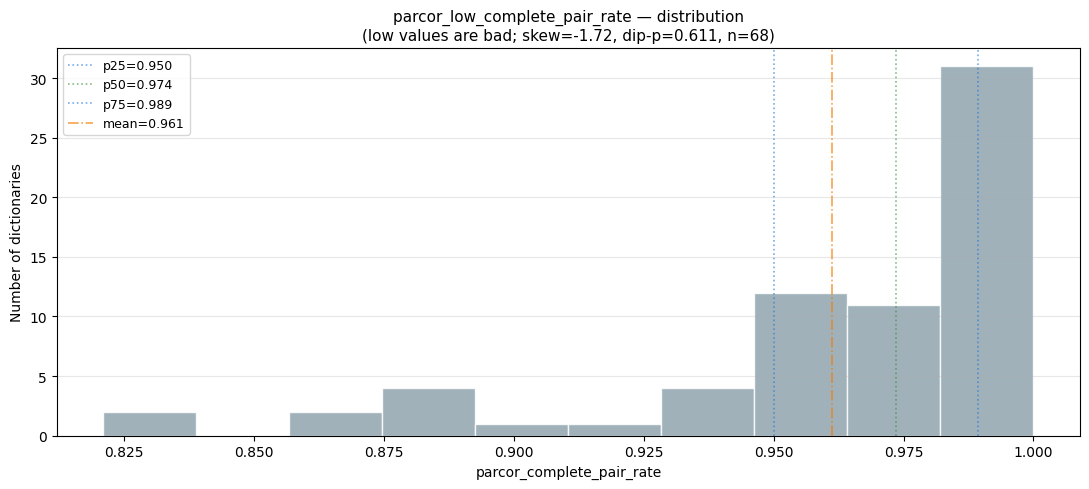


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_complete_pair_rate  prep_rows  billex_rows  morph_rows  parcor_rows
    1      11                     0.8210       2298          399         205          609
    2       8                     0.8257       2281          342         124          413
    3      78                     0.8617       1195            2           0          311
    4      58                     0.8714       5237           34           9         1532
    5      67                     0.8767       3135          162          65          511
    6      62                     0.8824       8739           92          63         3632
    7      26                     0.8832       4735         3137        1014          591
    8      34                     0.8899      11207         5730        2322         4407
    9      31                     0.8975       1371            1           0          566
   10      45                     0.9211      

In [15]:
explore_rule(
    rule_name="parcor_low_complete_pair_rate",
    metric_col="parcor_complete_pair_rate",
    direction="low",
)

## 16. `parcor_low_valid_length_rate`

**Metric:** `parcor_valid_length_rate`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts first)

_Renamed from `parcor_high_short_rows` (metric `parcor_short_rate`); flipped to positive framing for consistency with other rules._


=== parcor_low_valid_length_rate ===

Metric: parcor_valid_length_rate    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.2034    max: 0.9375
  mean: 0.6897    median: 0.7377    std: 0.1807
  skewness: -0.742    dip-test p-value: 0.9772
  shape hint: MILDLY SKEWED (left tail)

Percentiles:
  p1=0.2748  p5=0.3493  p10=0.4147  p25=0.5673
  p50=0.7377  p75=0.8304  p90=0.8892  p95=0.9114  p99=0.9292

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.3493 |      4 ( 5.9%) | quantile
  p10        |    0.4147 |      7 (10.3%) | quantile
  p25        |    0.5673 |     17 (25.0%) | quantile
  p50        |    0.7377 |     34 (50.0%) | quantile
  p75        |    0.8304 |     51 (75.0%) | quantile
  p90        |    0.8892 |     61 (89.7%) | quantile
  p95        |    0.9114 |     64 (94.1%) | quantile
  mean       |    0.6897 |     29 (42.6%) | landmark
  me

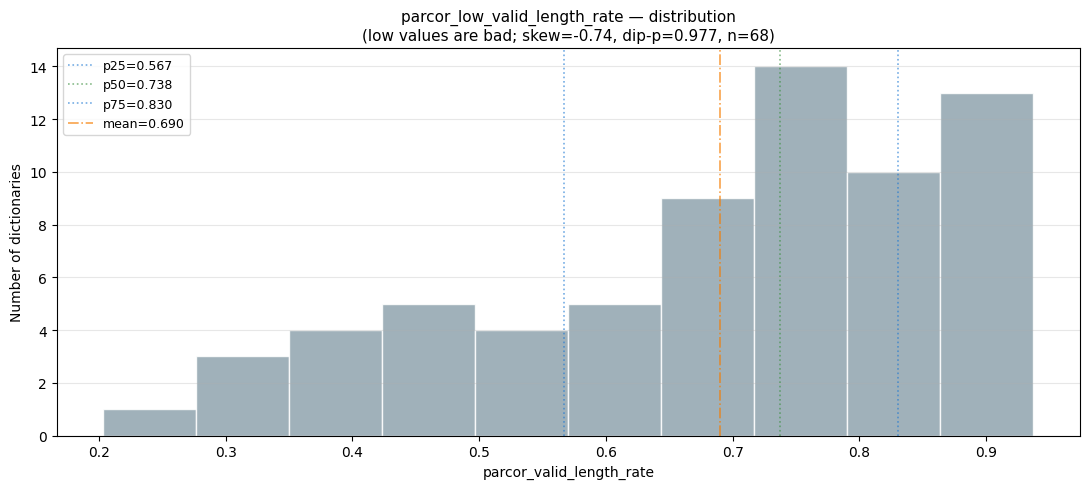


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_valid_length_rate  prep_rows  billex_rows  morph_rows  parcor_rows
    1       8                    0.2034       2281          342         124          413
    2       5                    0.3099       3853         2395         820          697
    3      18                    0.3439      14876         9877        2684         2341
    4      26                    0.3469       4735         3137        1014          591
    5      78                    0.3537       1195            2           0          311
    6      58                    0.3956       5237           34           9         1532
    7      84                    0.4015       1001            5           2          264
    8      11                    0.4204       2298          399         205          609
    9      62                    0.4306       8739           92          63         3632
   10      34                    0.4429      11207      

In [16]:
explore_rule(
    rule_name="parcor_low_valid_length_rate",
    metric_col="parcor_valid_length_rate",
    direction="low",
)

In [17]:
# ============================================================
# Concrete examples for billex single-word headwords and parcor short rows
#
# Shows actual offending content from a random dict for each rule,
# so you can see what the metric is actually measuring before
# deciding the threshold.
# ============================================================

import re
import ast
import random

EXAMPLES_PER_RULE = 10
RANDOM_SEED = 42

random.seed(RANDOM_SEED)


# ----- billex_single_word_headword_rate examples -----
# (the metric is now positive: "fraction of single-word headwords"; we sample
#  the multi-word entries — i.e., the entries the OLD rule would have flagged —
#  to show what's being measured)

print("=" * 70)
print("EXAMPLES: billex multi-word headwords")
print("(the entries that drag billex_single_word_headword_rate down)")
print("=" * 70)

# Pick a random dict that has at least some multi-word entries to sample from
billex_sub = metrics_df[
    metrics_df["billex_single_word_headword_rate"].notna() &
    (metrics_df["billex_single_word_headword_rate"] < 1.0) &
    (metrics_df["billex_single_word_headword_rate"] > 0)
].copy()

if len(billex_sub) == 0:
    print("(no usable billex data)")
else:
    target_row = billex_sub.sample(n=1, random_state=RANDOM_SEED).iloc[0]
    target_dict_id = target_row["dict_id"]
    target_rate = target_row["billex_single_word_headword_rate"]
    print(f"\nSampling from dict #{target_dict_id} (single-word rate: {target_rate:.1%})\n")

    billex_path = next(DIRS["billex"].glob(f"{target_dict_id}_*.csv"), None)
    if billex_path is None:
        print(f"(billex file for dict {target_dict_id} not found)")
    else:
        try:
            df_b = pd.read_csv(billex_path)
            direction = direction_for(target_dict_id, direction_lookup) or 1

            if direction == 1:
                ind_col = "kata_asal"
            else:
                ind_col = "kata_tujuan"

            def first_of_cell(v):
                if not isinstance(v, str): return ""
                try:
                    lst = ast.literal_eval(v)
                    if isinstance(lst, list) and lst:
                        return str(lst[0]).strip()
                except Exception:
                    pass
                return v.strip()

            if direction == 1:
                ind_series = df_b[ind_col].fillna("").astype(str).str.strip()
            else:
                ind_series = df_b[ind_col].apply(first_of_cell)

            multiword_mask = ind_series.str.contains(r"\s", na=False, regex=True)
            multiword_entries = ind_series[multiword_mask]

            if len(multiword_entries) == 0:
                print("(no multi-word entries in this dict)")
            else:
                n_to_show = min(EXAMPLES_PER_RULE, len(multiword_entries))
                sample_idx = random.sample(list(multiword_entries.index), n_to_show)
                print(f"  {n_to_show} example multi-word headwords:")
                for i, idx in enumerate(sample_idx, 1):
                    headword = multiword_entries.loc[idx]
                    target = df_b.loc[idx, "kata_tujuan" if direction == 1 else "kata_asal"]
                    target_str = first_of_cell(target) if direction == 0 else (target if isinstance(target, str) else "")
                    print(f"    {i:>2}. \"{headword}\"  →  {target_str[:60]}")
        except Exception as e:
            print(f"(error reading billex: {e})")


# ----- parcor_valid_length_rate examples -----
# (we sample the short rows — i.e., the entries the OLD rule would have flagged)

print("\n" + "=" * 70)
print("EXAMPLES: parcor short rows")
print("(the entries that drag parcor_valid_length_rate down)")
print("=" * 70)

parcor_sub = metrics_df[
    metrics_df["parcor_valid_length_rate"].notna() &
    (metrics_df["parcor_valid_length_rate"] < 1.0)
].copy()

if len(parcor_sub) == 0:
    print("(no usable parcor data)")
else:
    target_row = parcor_sub.sample(n=1, random_state=RANDOM_SEED).iloc[0]
    target_dict_id = target_row["dict_id"]
    target_rate = target_row["parcor_valid_length_rate"]
    print(f"\nSampling from dict #{target_dict_id} (valid-length rate: {target_rate:.1%})\n")

    parcor_path = next(DIRS["parcor"].glob(f"{target_dict_id}_*.csv"), None)
    if parcor_path is None:
        print(f"(parcor file for dict {target_dict_id} not found)")
    else:
        try:
            df_p = pd.read_csv(parcor_path)

            if "kalimat_asal" not in df_p.columns or "kalimat_tujuan" not in df_p.columns:
                print("(parcor file missing required columns)")
            else:
                len_asal = df_p["kalimat_asal"].fillna("").astype(str).apply(
                    lambda s: len(s.split())
                )
                len_tujuan = df_p["kalimat_tujuan"].fillna("").astype(str).apply(
                    lambda s: len(s.split())
                )
                short_mask = (len_asal <= 2) | (len_tujuan <= 2)
                short_entries = df_p[short_mask]

                if len(short_entries) == 0:
                    print("(no short rows in this dict)")
                else:
                    n_to_show = min(EXAMPLES_PER_RULE, len(short_entries))
                    sample_idx = random.sample(list(short_entries.index), n_to_show)
                    print(f"  {n_to_show} example short rows:")
                    for i, idx in enumerate(sample_idx, 1):
                        ind = str(df_p.loc[idx, "kalimat_asal"])[:50]
                        reg = str(df_p.loc[idx, "kalimat_tujuan"])[:50]
                        n_ind = len(ind.split())
                        n_reg = len(reg.split())
                        print(f"    {i:>2}. ind ({n_ind:>2}t): \"{ind}\"")
                        print(f"        reg ({n_reg:>2}t): \"{reg}\"")
        except Exception as e:
            print(f"(error reading parcor: {e})")


EXAMPLES: billex multi-word headwords
(the entries that drag billex_single_word_headword_rate down)

Sampling from dict #1 (single-word rate: 31.2%)

  10 example multi-word headwords:
     1. "sang si sang kat"  →  ['si hamba']
     2. "callamilerek nama sebilah kerfs  calle calle-calle leher kandungan rahim callik semacilm bimyi kerasatauteriakan karen"  →  []
     3. "bingkasak lunglai karen"  →  ['bingkung cangkul']
     4. "iruk imp himp anngiruk menghimp mengisap air atau bend"  →  []
     5. "pada  padompe pad"  →  ['pada-pada sarna-sarna', 'serentak']
     6. "ladang beranda paludang beranda aljjmempoi"  →  []
     7. "f ka b b k"  →  []
     8. "nawa  nawa kedalarn bah as"  →  ['indoensia']
     9. "gatta  gegerek kaniakmakik  syukur karen"  →  []
    10. "gawe pegawe pegawai  gay"  →  ['gaya', 'sikap', 'tingkah laku']

EXAMPLES: parcor short rows
(the entries that drag parcor_valid_length_rate down)

Sampling from dict #55 (valid-length rate: 78.3%)

  10 example short rows:


## 17. Combined per-rule distributions CSV

A single wide-format CSV with each dict's value for every rule. Use this
for cross-rule analysis (e.g., "do dicts with low tag_coverage also have
low retention?").

In [18]:
combined_cols = ["dict_id", "prep_rows", "direction"]
metric_cols = [
    "morph_tag_coverage", "morph_rows", "morph_retention",
    "billex_single_word_headword_rate", "billex_rows", "billex_complete_pair_rate", "billex_retention",
    "parcor_valid_content_rate", "parcor_rows", "parcor_retention",
    "parcor_complete_pair_rate", "parcor_valid_length_rate",
]
existing = [c for c in metric_cols if c in metrics_df.columns]
combined = metrics_df[combined_cols + existing].copy()
combined.to_csv(DST_DIR / "_per_rule_distributions.csv", index=False)
print(f"Wrote: {DST_DIR / '_per_rule_distributions.csv'}  ({len(combined)} dicts × {len(combined.columns)} cols)")
combined.head(10)


Wrote: ..\csvAnalysis\distribution_exploration_1\_per_rule_distributions.csv  (68 dicts × 15 cols)


,dict_id,prep_rows,direction,morph_tag_coverage,morph_rows,morph_retention,billex_single_word_headword_rate,billex_rows,billex_complete_pair_rate,billex_retention,parcor_valid_content_rate,parcor_rows,parcor_retention,parcor_complete_pair_rate,parcor_valid_length_rate
0,1,3986,0,0.0000,6,0.001505,0.3125,16,1.000,0.0040,0.9925,2914,0.731059,0.9925,0.6764
1,2,4752,0,0.2500,12,0.002525,0.5658,76,1.000,0.0160,0.6590,2047,0.430766,0.9487,0.6155
2,3,833,0,0.0000,1,0.001200,0.1053,19,1.000,0.0228,0.4960,125,0.150060,0.9600,0.7200
3,4,3212,1,0.5412,728,0.226650,0.8807,1894,1.000,0.5897,0.3473,2658,0.827522,0.9989,0.8856
4,5,3853,1,0.6841,820,0.212821,0.8154,2395,1.000,0.6216,0.9986,697,0.180898,0.9713,0.3099
5,8,2281,1,0.2016,124,0.054362,0.7632,342,1.000,0.1499,0.8838,413,0.181061,0.8257,0.2034
6,9,2240,0,0.0000,8,0.003571,0.0870,23,1.000,0.0103,0.6683,1049,0.468304,0.9561,0.6120
7,10,5260,1,0.8542,1125,0.213878,0.9116,3800,1.000,0.7224,0.3362,2942,0.559316,0.9966,0.9133
8,11,2298,0,0.1366,205,0.089208,0.6366,399,0.995,0.1736,0.6125,609,0.265013,0.8210,0.4204
9,12,9400,1,0.6726,2645,0.281383,0.7789,6192,1.000,0.6587,0.6162,4810,0.511702,0.9638,0.5466


## 18. Decision template

Empty template for you to fill in your chosen thresholds. After making
decisions per rule, fill in the `chosen_threshold` column. The next sanity
check iteration can read this CSV directly.

In [19]:
template_rows = []
rules_meta = [
    ("morph_low_tag_coverage",                 "morph_tag_coverage",                "low"),
    ("morph_too_few_rows",                     "morph_rows",                        "low"),
    ("morph_low_retention",                    "morph_retention",                   "low"),
    ("billex_low_single_word_headword_rate",   "billex_single_word_headword_rate",  "low"),
    ("billex_too_few_rows",                    "billex_rows",                       "low"),
    ("billex_low_complete_pair_rate",          "billex_complete_pair_rate",         "low"),
    ("billex_low_retention",                   "billex_retention",                  "low"),
    ("parcor_low_valid_content_rate",          "parcor_valid_content_rate",         "low"),
    ("parcor_too_few_rows",                    "parcor_rows",                       "low"),
    ("parcor_low_retention",                   "parcor_retention",                  "low"),
    ("parcor_low_complete_pair_rate",          "parcor_complete_pair_rate",         "low"),
    ("parcor_low_valid_length_rate",           "parcor_valid_length_rate",          "low"),
]
for rule_name, metric_col, direction in rules_meta:
    template_rows.append({
        "rule_name":         rule_name,
        "metric_column":     metric_col,
        "direction":         direction,
        "chosen_threshold":  "",
        "rationale":         "",
        "decided_on":        "",
    })
template_df = pd.DataFrame(template_rows)
template_df.to_csv(DST_DIR / "_my_thresholds.csv", index=False)
print(f"Wrote decision template: {DST_DIR / '_my_thresholds.csv'}")
print(f"\nFill in the 'chosen_threshold' column for each rule, then save.")
template_df


Wrote decision template: ..\csvAnalysis\distribution_exploration_1\_my_thresholds.csv

Fill in the 'chosen_threshold' column for each rule, then save.


,rule_name,metric_column,direction,chosen_threshold,rationale,decided_on
0,morph_low_tag_coverage,morph_tag_coverage,low,,,
1,morph_too_few_rows,morph_rows,low,,,
2,morph_low_retention,morph_retention,low,,,
3,billex_low_single_word_headword_rate,billex_single_word_headword_rate,low,,,
4,billex_too_few_rows,billex_rows,low,,,
5,billex_low_complete_pair_rate,billex_complete_pair_rate,low,,,
6,billex_low_retention,billex_retention,low,,,
7,parcor_low_valid_content_rate,parcor_valid_content_rate,low,,,
8,parcor_too_few_rows,parcor_rows,low,,,
9,parcor_low_retention,parcor_retention,low,,,


Wrote: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\distribution_exploration_1\_all_9_rule_distributions.png


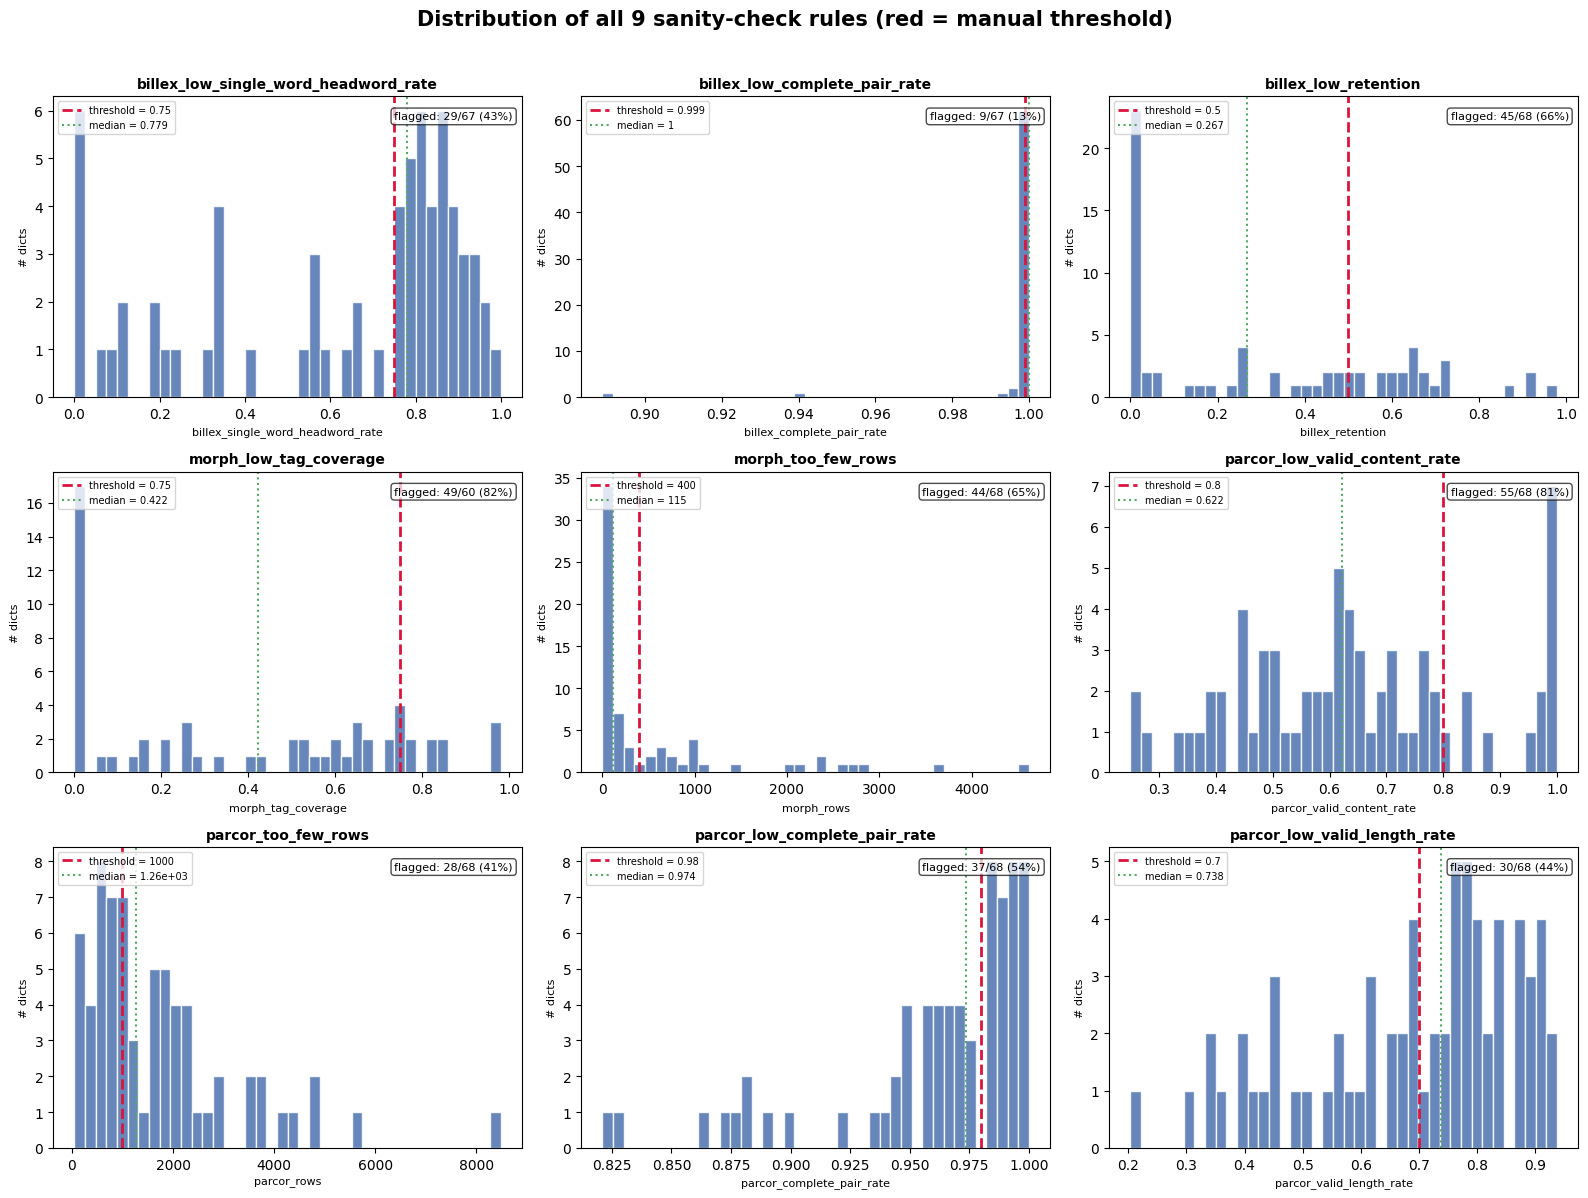

In [20]:
# ============================================================
# Combined distribution grid — all 9 active rules in one PNG
#
# Renders a 3×3 grid of histograms (one per rule) with the
# manually-set threshold drawn as a red dashed line, and saves
# the figure to the output dir as a single .png.
# ============================================================

# (rule_name, metric_col, threshold)  — order matches the 3 categories in the docs
NINE_RULES = [
    ("billex_low_single_word_headword_rate", "billex_single_word_headword_rate", 0.75),
    ("billex_low_complete_pair_rate",        "billex_complete_pair_rate",        0.999),
    ("billex_low_retention",                 "billex_retention",                 0.50),
    ("morph_low_tag_coverage",               "morph_tag_coverage",               0.75),
    ("morph_too_few_rows",                   "morph_rows",                       400),
    ("parcor_low_valid_content_rate",        "parcor_valid_content_rate",        0.80),
    ("parcor_too_few_rows",                  "parcor_rows",                      1000),
    ("parcor_low_complete_pair_rate",        "parcor_complete_pair_rate",        0.98),
    ("parcor_low_valid_length_rate",         "parcor_valid_length_rate",         0.70),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for ax, (rule_name, metric_col, threshold) in zip(axes, NINE_RULES):
    if metric_col not in metrics_df.columns:
        ax.text(0.5, 0.5, f"{metric_col}\nnot in metrics_df",
                ha="center", va="center", transform=ax.transAxes, color="crimson")
        ax.set_title(rule_name, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        continue

    values = metrics_df[metric_col].dropna().values.astype(float)
    if len(values) < 1:
        ax.text(0.5, 0.5, "no data", ha="center", va="center",
                transform=ax.transAxes, color="crimson")
        ax.set_title(rule_name, fontsize=10)
        continue

    n_flagged = int((values < threshold).sum())  # all rules are direction="low"
    n_total = len(values)

    ax.hist(values, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(threshold, color="crimson", linestyle="--", linewidth=2,
               label=f"threshold = {threshold:g}")
    ax.axvline(np.median(values), color="#55A868", linestyle=":", linewidth=1.5,
               label=f"median = {np.median(values):.3g}")

    ax.set_title(rule_name, fontsize=10, fontweight="bold")
    ax.set_xlabel(metric_col, fontsize=8)
    ax.set_ylabel("# dicts", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
    ax.text(0.98, 0.95,
            f"flagged: {n_flagged}/{n_total} ({n_flagged/n_total:.0%})",
            ha="right", va="top", transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

fig.suptitle("Distribution of all 9 sanity-check rules (red = manual threshold)",
             fontsize=15, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])

out_path = DST_DIR / "_all_9_rule_distributions.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Wrote: {out_path.resolve()}")
plt.show()

## How to use this notebook

For each rule:

1. **Read the diagnostics** at the top: does the data look bimodal,
   skewed, symmetric? This shapes your intuition.
2. **Look at the what-if table**: do any of the candidate thresholds
   produce a flag count that matches your intuition for "how many should
   be bad"?
3. **Look at the histogram**: where does the distribution have natural
   gaps or breaks?
4. **Open the per-rule CSV**: scan the top of the ranked list. Where
   does the metric value transition from "this is clearly bad" to
   "this is acceptable"?
5. **Decide your threshold and write it in `_my_thresholds.csv`** along
   with a one-sentence rationale.

The rationale matters because it's what you'll defend to your advisor.
"At p25 the threshold flags 17 dicts which roughly matches the
catastrophic failure count" is defensible. "I picked 0.3 because it
felt right" is not.

For some rules the right threshold may be 0 (only literally-empty cases
are bad). For others it may be high (most dicts are bad and only a few
clean ones pass). The point is to look at each rule's own evidence and
decide based on that, not on a universal recipe.